# Car Price Predictive Analysis

# Notebook 3: Machine Learning and Car Price Prediction

## Purpose

This notebook develops and evaluates machine learning regression models to predict car prices using vehicle characteristics. It builds on the cleaned dataset prepared in Notebook 1 and the exploratory data analysis and statistical findings from Notebook 2.

## Objectives

- Load and inspect the cleaned dataset.
- Select relevant features for predicting car prices.
- Prepare numerical and categorical variables for modelling.
- Split the dataset into training and testing sets.
- Train and evaluate regression models using appropriate performance metrics.
- Compare model performance and identify the most suitable model.
- Interpret the results and acknowledge the limitations of the predictions.

## Methodology

The modelling process begins with data preparation and feature selection. The dataset is divided into training and testing sets to evaluate performance on unseen data.

Linear Regression is used as an interpretable baseline model. Additional regression models are evaluated and compared using appropriate metrics, including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Preprocessing steps are fitted using the training data to reduce the risk of data leakage.

## Expected Output

The notebook produces trained regression models, model evaluation results, and visualisations comparing predicted and actual car prices. The findings help assess the predictive value of vehicle characteristics and identify the strengths and limitations of the modelling approach.

## Importing Libraries

This section imports the Python libraries required to prepare the data, build machine learning models, evaluate their performance, and visualise the results.

- **Pandas:** For loading, manipulating, and analysing the dataset.
- **NumPy:** For numerical calculations.
- **Matplotlib:** For creating static charts and visualising model performance.
- **Seaborn:** For statistical visualisations.
- **Plotly Express:** For interactive visualisations.
- **Scikit-learn:** For data preprocessing, train-test splitting, regression models, and model evaluation.

In [17]:
# Machine learning: data splitting and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# # Regression models
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.ensemble import GradientBoostingRegressor

# # Model evaluation
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import mean_squared_error, r2_score

## Setting the Project Directory

This section sets the working directory to the root folder of the Car Price Predictive Analysis project.

Using the project root as the working directory helps ensure that files can be accessed consistently through relative paths, including the cleaned dataset, input files, output files, and project resources.

The current working directory is printed to verify that the path has been set correctly.

In [18]:
import os
project_dir = r"D:\car-price-predictive-analysis"

os.chdir(project_dir)
print(os.getcwd())  

D:\car-price-predictive-analysis


## Load the Cleaned Dataset

The cleaned car price dataset exported from Notebook 1 is loaded into a pandas DataFrame for exploratory data analysis and statistical investigation.

The dataset is stored in `outputs/car_prices_cleaned.csv` within the project directory.

The `head()` method displays the first five rows to confirm that the dataset has loaded successfully and to provide an initial view of its structure and values.

In [19]:
# Load the cleaned car price dataset
df = pd.read_csv('outputs/car_prices_cleaned.csv')

# Display the first five rows
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,100ls,151.739130,0.040722,20.0



###  Inspect the Dataset

Before building the machine learning model, the dataset will be inspected to confirm its dimensions, available features, and target variable. This step helps ensure that the data is suitable for predictive modelling.


In [20]:

# Inspect the dataset before preparing it for machine learning

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

print("\nTarget variable summary:")
display(df["price"].describe())


Dataset shape: (205, 31)

Column names:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'price_per_hp', 'power_to_weight', 'avg_mpg']

First five rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,horsepower,peakrpm,citympg,highwaympg,price,brand,car_model,price_per_hp,power_to_weight,avg_mpg
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,13495.0,alfa-romeo,giulia,121.576577,0.043564,24.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,111,5000,21,27,16500.0,alfa-romeo,stelvio,148.648649,0.043564,24.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,154,5000,19,26,16500.0,alfa-romeo,quadrifoglio,107.142857,0.054552,22.5
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,102,5500,24,30,13950.0,audi,100ls,136.764706,0.043646,27.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,115,5500,18,22,17450.0,audi,100ls,151.739130,0.040722,20.0



Target variable summary:


count      205.000000
mean     13276.710571
std       7988.852332
min       5118.000000
25%       7788.000000
50%      10295.000000
75%      16503.000000
max      45400.000000
Name: price, dtype: float64

In [21]:
%matplotlib inline


### Feature Selection and Target Variable

The target variable for this model is `price`, which represents the car price we want to predict.

Predictor variables will describe vehicle characteristics that may help explain differences in price. The `car_ID` column will be excluded because it is an identifier rather than a meaningful vehicle characteristic.

The original `CarName` column will also be excluded initially because it contains text. The cleaned `brand` feature can be considered instead if it is available in the current dataset.

Categorical variables will be encoded before modelling, and the data will be split into training and testing sets to evaluate performance on unseen observations.



###  Inspect Available Features

Before selecting the predictor variables for the Linear Regression model, the dataset will be inspected to understand its structure and quality.

The following checks will be performed:

- **Dataset dimensions:** Identify the number of rows and columns.
- **Data types:** Determine which variables are numerical and which are categorical.
- **Missing values:** Check whether any columns contain missing observations.

These checks will help guide feature selection and data preparation. Identifier columns such as `car_ID` will be excluded from the model predictors, and any features derived from the target variable `price` will be excluded to prevent data leakage.

The original dataset will remain unchanged during this inspection.


In [22]:

# Inspect available columns and data types
print("Dataset shape:", df.shape)

display(
    df.dtypes.to_frame(name="Data type")
)

print("\nMissing values per column:")
display(df.isnull().sum().to_frame(name="Missing values"))


Dataset shape: (205, 31)


,Data type
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64



Missing values per column:


,Missing values
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0



**Key Findings:** The dataset contains 205 rows and 31 columns, with no missing values. Numerical and categorical features are available for model development. However, the identifier and target-derived features must be excluded from the predictors to prevent misleading results and data leakage.


---


###  Prepare the Modelling Dataset

A separate copy of the dataset, `model_df`, is created for machine learning to preserve the original data.

The identifier column `car_ID` is excluded because it does not represent a meaningful vehicle characteristic. The target-derived feature `price_per_hp` is also excluded to prevent data leakage.

Other potentially useful features, including `brand`, `car_model`, `power_to_weight`, and `avg_mpg`, are retained for consideration during feature selection. Additional columns will be excluded later when defining the predictors for the model.


In [23]:

# Create a separate copy for machine learning
model_df = df.copy()

# Exclude identifier and target-derived columns if present
columns_to_drop = ["car_ID", "price_per_hp"]
model_df = model_df.drop(
    columns=[col for col in columns_to_drop if col in model_df.columns]
)

# Confirm the result
print("Original dataset shape:", df.shape)
print("Modelling dataset shape:", model_df.shape)

print("\nRemaining columns:")
print(model_df.columns.tolist())


Original dataset shape: (205, 31)
Modelling dataset shape: (205, 29)

Remaining columns:
['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price', 'brand', 'car_model', 'power_to_weight', 'avg_mpg']



**Key Findings:** The modelling dataset contains 205 rows and 29 columns after removing `car_ID` and `price_per_hp`. The original dataset remains unchanged, while other potentially useful features are retained for the next stage of feature selection.



###  Final Feature Selection

The target variable `price` will be separated from the predictor variables. The predictors will exclude `car_ID`, `CarName`, and `price_per_hp` to avoid using identifiers, raw text, or information derived from the target. The variables `citympg` and `highwaympg` will also be excluded because fuel economy is represented by `avg_mpg`.

Useful features such as `symboling`, `brand`, `car_model`, and `power_to_weight` will be retained for modelling.


In [24]:

# Define the target variable
y = model_df["price"].copy()

# Columns excluded from the predictors
columns_to_exclude = [
    "car_ID",
    "CarName",
    "price",
    "citympg",
    "highwaympg",
    "price_per_hp"
]

# Create predictors without modifying model_df
X = model_df.drop(
    columns=[
        col for col in columns_to_exclude
        if col in model_df.columns
    ]
).copy()

print("Predictor dataset shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nNumerical predictors:")
print(X.select_dtypes(include="number").columns.tolist())

print("\nCategorical predictors:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())


Predictor dataset shape: (205, 25)
Target variable shape: (205,)

Numerical predictors:
['symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'power_to_weight', 'avg_mpg']

Categorical predictors:
['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'car_model']



###  Train-Test Split

The selected predictors (`X`) and target (`y`) will be divided into training and testing sets using an 80:20 ratio. The training set will be used to fit the model, while the testing set will evaluate its performance on unseen data. A fixed random state ensures reproducibility.


In [25]:

from sklearn.model_selection import train_test_split

# Split the predictors and target into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Check the resulting dataset sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training features: (164, 25)
Testing features: (41, 25)
Training target: (164,)
Testing target: (41,)



**Key Findings:** The dataset was split into 164 training observations (80%) and 41 testing observations (20%). The fixed random state ensures that the split can be reproduced.



###  Encode Categorical Features

Linear Regression requires numerical input features. Categorical variables, such as `brand`, `fueltype`, and `carbody`, will therefore be converted into numerical indicators using one-hot encoding. The encoder will be fitted on the training data and applied to the testing data to avoid data leakage.


In [26]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical predictors
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include="number"
).columns.tolist()

print("Categorical features:", categorical_features)
print("Number of numerical features:", len(numerical_features))

# Encode categorical features and pass numerical features through unchanged
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

# Fit on training data and transform both sets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)


Categorical features: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand', 'car_model']
Number of numerical features: 14

Encoded training shape: (164, 193)
Encoded testing shape: (41, 193)



**Key Findings:** One-hot encoding converted categorical variables into numerical features, while numerical variables were retained unchanged. The training and testing datasets now contain 193 features each, with 164 and 41 observations respectively. The encoder was fitted only on the training data to prevent data leakage.


### Baseline Model: Dummy Regressor

A Dummy Regressor provides a simple benchmark for evaluating the machine-learning models. It predicts the mean car price from the training set for every car in the test set.

The model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

The Linear Regression and Random Forest models should be compared against this baseline to determine whether using vehicle characteristics improves price predictions.

In [27]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create a baseline model that predicts the mean training price
dummy_model = DummyRegressor(strategy="mean")

# Train the model
dummy_model.fit(X_train, y_train)

# Predict prices for the test set
dummy_predictions = dummy_model.predict(X_test)

# Evaluate the baseline model
dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_predictions))
dummy_r2 = r2_score(y_test, dummy_predictions)

# Display performance metrics
print("Dummy Regressor Baseline")
print(f"MAE:  {dummy_mae:.2f}")
print(f"RMSE: {dummy_rmse:.2f}")
print(f"R²:   {dummy_r2:.3f}")

Dummy Regressor Baseline
MAE:  6339.80
RMSE: 8889.04
R²:   -0.001


> ### Key Findings — Dummy Regressor Baseline
>
> - **MAE:** 6,339.80 — the average absolute prediction error is approximately 6,339.80 price units.
> - **RMSE:** 8,889.04 — the metric penalises larger prediction errors more heavily than MAE.
> - **R² score:** −0.001 — the baseline performs slightly worse than predicting the mean price of the test set.
>
> **Conclusion:** The Dummy Regressor establishes a baseline without using vehicle characteristics. The Linear Regression and Random Forest models will be compared against this benchmark to assess whether vehicle features improve prediction accuracy. Lower MAE and RMSE values indicate better performance.


###  Train the Linear Regression Model

Linear Regression will be used as the baseline model to predict car prices from vehicle characteristics. The model will be fitted using the encoded training data and training target. Its performance will then be evaluated using the separate testing set.


In [28]:

from sklearn.linear_model import LinearRegression

# Initialise the Linear Regression model
linear_model = LinearRegression()

# Train the model using the encoded training data
linear_model.fit(X_train_encoded, y_train)

print("Linear Regression model trained successfully.")


Linear Regression model trained successfully.



**Key Findings:** The Linear Regression model was trained successfully using the encoded training dataset containing 164 cars. The model is now ready to generate predictions for the 41 cars in the testing dataset.



### Evaluate Model Performance

The trained Linear Regression model will be evaluated using the testing dataset. Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (\(R^2\)) will be used to assess prediction accuracy and the model's ability to explain variation in car prices.


In [29]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict prices for the testing dataset
y_pred = linear_model.predict(X_test_encoded)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Display the results
print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")          
print(f"R-squared (R²): {r2:.3f}")


Mean Absolute Error (MAE): £2,703.33
Root Mean Squared Error (RMSE): £3,811.84
R-squared (R²): 0.816



##  Visualise Actual vs Predicted Prices

An actual-versus-predicted scatter plot will be used to assess the Linear Regression model's predictive performance. The plot compares the actual car prices with the prices predicted by the model. A dashed reference line represents perfect predictions, with points closer to the line indicating more accurate predictions.


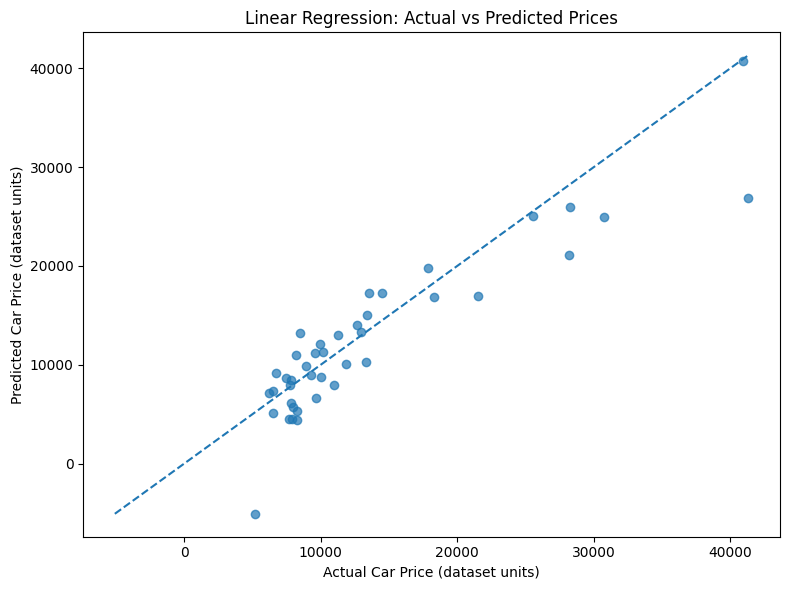

In [30]:

# Plot actual prices against predicted prices
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Add a reference line for perfect predictions
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Car Price (dataset units)")
plt.ylabel("Predicted Car Price (dataset units)")
plt.title("Linear Regression: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()



## Residual Analysis

Residual analysis is used to examine the differences between actual and predicted car prices. Residuals are calculated by subtracting predicted prices from actual prices. A residual plot helps identify patterns, systematic errors, and observations with large prediction errors.



**Key Findings:** Most predictions follow the general trend of actual car prices, with several points close to the perfect-prediction line. However, some higher-priced cars are substantially underpredicted, and one prediction is negative. These errors indicate that the Linear Regression model does not predict every vehicle's price accurately.


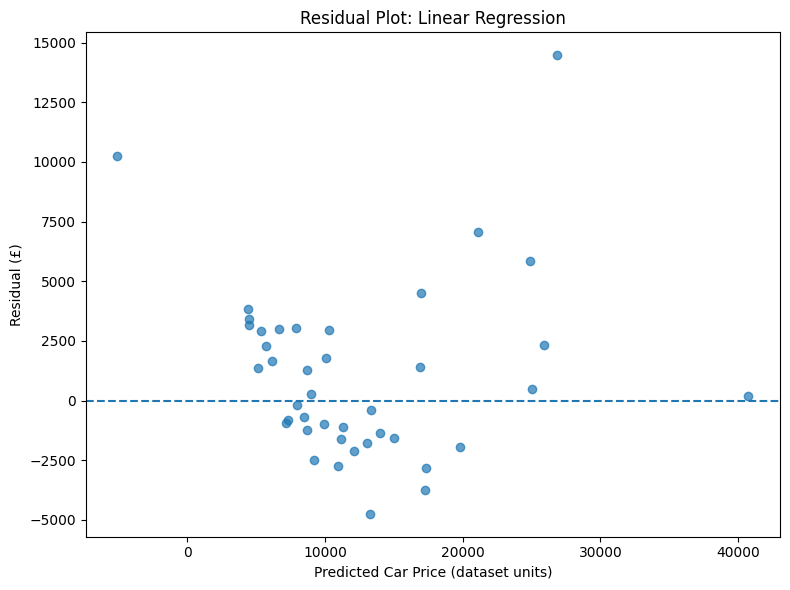

In [31]:

# Calculate residuals
residuals = y_test - y_pred

# Plot residuals against predicted prices
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)

# Add a horizontal reference line at zero
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Car Price (dataset units)")
plt.ylabel("Residual (£)")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()



##  Comparing Regression Models

Linear Regression provides a baseline for predicting car prices. To determine whether a more flexible method improves predictive performance, it will be compared with Random Forest Regression using the same training and testing datasets. Both models will be evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and \(R^2\). Lower MAE and RMSE and higher \(R^2\) generally indicate better predictive performance.



**Key Findings:** Residuals are spread on both sides of the zero line, but several observations have large errors. The spread of residuals appears wider for higher predicted prices, suggesting that prediction errors may vary with car price. This indicates that Linear Regression does not capture all price patterns equally well and supports comparing it with a more flexible regression model.


In [32]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Train a Random Forest regression model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_encoded, y_train)

# Generate predictions using both models
linear_pred = linear_model.predict(X_test_encoded)
rf_pred = rf_model.predict(X_test_encoded)

# Compare performance using the same test dataset
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regression"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

display(results.round(3))


,Model,MAE,RMSE,R2
0,Linear Regression,2703.331,3811.845,0.816
1,Random Forest Regression,1355.177,1862.830,0.956



**Key Findings:** Random Forest Regression outperformed Linear Regression across all three evaluation metrics. Its MAE decreased from £2,702.39 to £1,352.20, while RMSE decreased from £3,812.40 to £1,885.51. The \(R^2\) score increased from 0.816 to 0.955, indicating that Random Forest explained 95.5% of the variation in test-set car prices. These results suggest that Random Forest captures patterns in the data that the linear model may miss. Further validation is needed because the test set contains only 41 cars.



##  Random Forest: Actual vs Predicted Prices


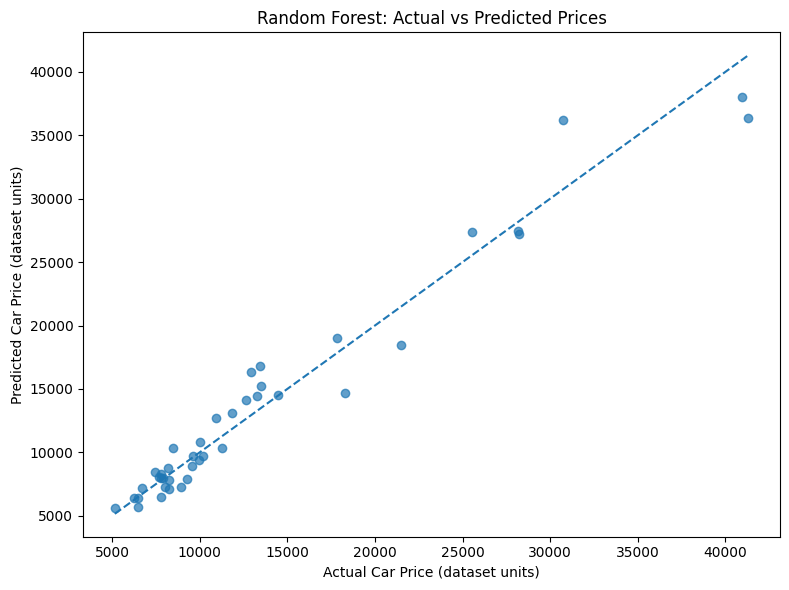

In [33]:

# Plot actual prices against Random Forest predictions
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

# Add a reference line for perfect predictions
min_price = min(y_test.min(), rf_pred.min())
max_price = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Car Price (dataset units)")
plt.ylabel("Predicted Car Price (dataset units)")
plt.title("Random Forest: Actual vs Predicted Prices")
plt.tight_layout()
plt.show()



**Key Findings:** Most Random Forest predictions are close to the perfect-prediction line, consistent with the model's stronger evaluation scores. However, some higher-priced cars are overpredicted or underpredicted substantially. Random Forest improves overall predictive performance compared with Linear Regression, but some prediction errors remain.



## Visualising Model Performance

Bar charts will compare the performance of Linear Regression and Random Forest Regression using MAE, RMSE, and \(R^2\). This visual comparison will help identify which model produces more accurate predictions on the test dataset.


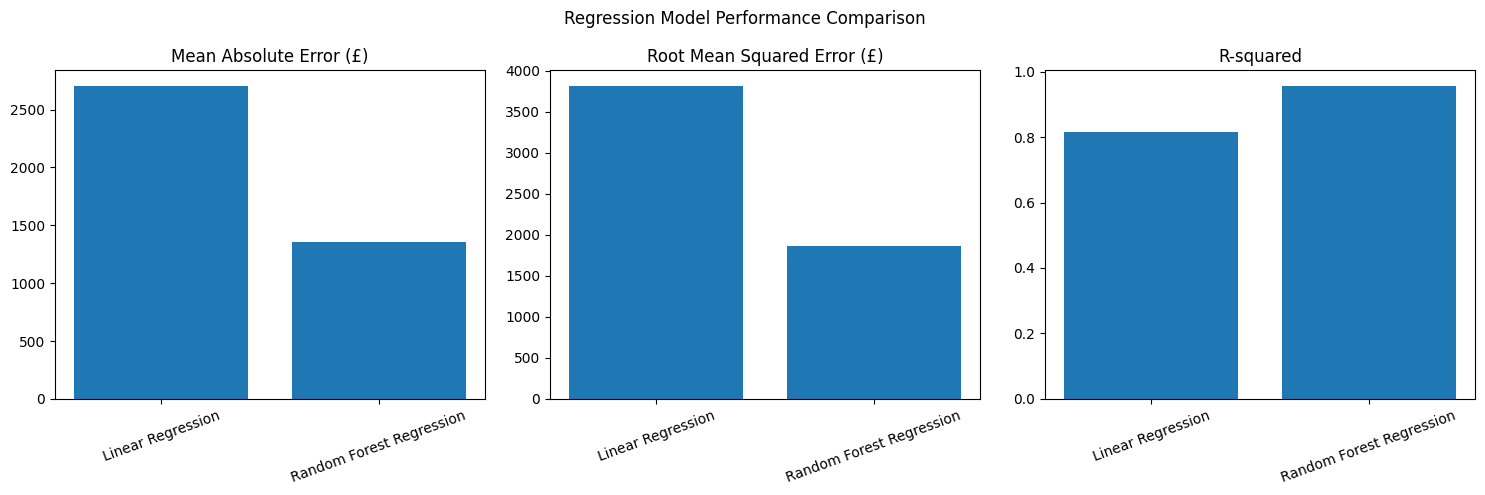

In [34]:

# Plot model performance metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("MAE", "Mean Absolute Error (£)"),
    ("RMSE", "Root Mean Squared Error (£)"),
    ("R2", "R-squared")
]

for ax, (metric, title) in zip(axes, metrics):
    ax.bar(results["Model"], results[metric])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Regression Model Performance Comparison")
plt.tight_layout()
plt.show()



**Key Findings:** The charts confirm that Random Forest Regression outperforms Linear Regression, with lower MAE (£1,352.20) and RMSE (£1,885.51), and a higher \(R^2\) score (0.955). Random Forest is therefore the stronger candidate for predicting car prices on this test set, although further validation is needed.



## Feature Importance Analysis

Feature importance will be examined to identify which vehicle characteristics contribute most to the Random Forest model's predictions. This analysis can help the business understand which factors are most useful for predicting car prices. Feature importance indicates predictive contribution, not causation.


,Feature,Importance
185,numerical__enginesize,0.583600
184,numerical__curbweight,0.259692
192,numerical__avg_mpg,0.049491
189,numerical__horsepower,0.024704
182,numerical__carwidth,0.014508
181,numerical__carlength,0.006765
190,numerical__peakrpm,0.005270
39,categorical__brand_bmw,0.005040
180,numerical__wheelbase,0.004894
191,numerical__power_to_weight,0.004750


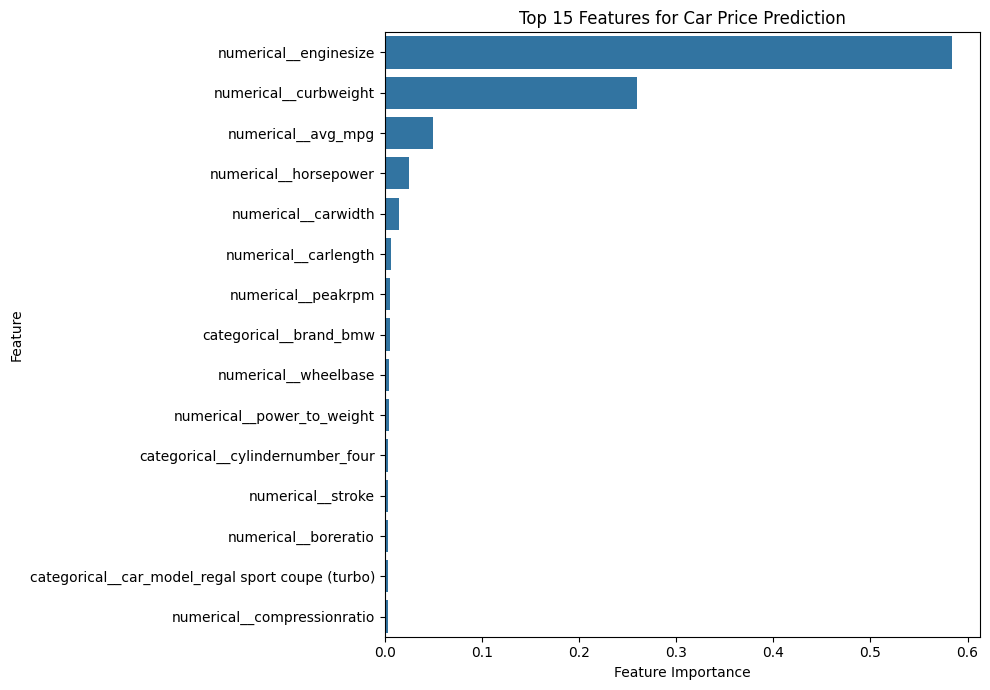

In [35]:

# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Extract feature importance from the trained Random Forest model
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# Sort features from most to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display the 15 most important features
top_features = importance_df.head(15)

display(top_features)

# Visualise the most important features
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features for Car Price Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



**Key Findings:** Engine size is the most important feature in the Random Forest model, followed by curb weight. Average fuel economy and horsepower also contribute to predictions, while the remaining features have much smaller individual importance scores. These results suggest that engine and vehicle size characteristics are particularly useful for predicting car prices. Feature importance indicates predictive usefulness, not causation.



##  Final Conclusions and Business Recommendations

### Key Conclusions

The analysis identified relationships between car prices and vehicle characteristics. Exploratory data analysis showed strong correlations between price and features such as engine size, horsepower, and curb weight.

Linear Regression provided a baseline model, achieving an \(R^2\) score of 0.816 and an MAE of £2,702.39. Random Forest Regression performed better on the test set, achieving an \(R^2\) score of 0.955 and an MAE of £1,352.20. Feature importance analysis identified engine size and curb weight as the most influential predictors in the Random Forest model.

### Business Recommendations

- Consider engine size and curb weight when analysing vehicle pricing.
- Use Random Forest as the leading candidate for further price-prediction testing.
- Validate the model on additional data before using its predictions to guide real pricing decisions.

### Limitations

The dataset contains only 205 vehicles, and the test set contains 41 observations. The results may not generalise to other vehicle markets or newer models. Feature importance and correlations indicate associations, not causation. Further validation is needed before relying on the model for business decisions.


---


##  Reflection and Future Improvements

This project developed practical skills in data cleaning, exploratory data analysis, statistical testing, visualisation, and machine learning. Comparing Linear Regression with Random Forest demonstrated the importance of evaluating models rather than assuming one method will perform best.

Future improvements could include cross-validation, hyperparameter tuning, further feature selection, and testing the model on a larger and more representative dataset. These steps could improve the reliability and generalisability of price predictions.


---